In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Clean white style
sns.set_style("white")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/broadway-datasets/NYCTheaters.csv
/kaggle/input/broadway-datasets/Best_Musical.csv
/kaggle/input/broadway-datasets/Best_Play.csv
/kaggle/input/broadway-datasets/Weekly_grosses.csv


# Exploring Attendance and Gross Revenue

In [2]:
pd_weekly_grosses = pd.read_csv("/kaggle/input/broadway-datasets/Weekly_grosses.csv")
pd_weekly_grosses.head()

# Data cleaning
pd_weekly_grosses["Week Ending"] = pd.to_datetime(pd_weekly_grosses["Week Ending"].apply(lambda x: datetime.strptime(x,'%b %d, %Y')))
pd_weekly_grosses["Month"] = pd_weekly_grosses["Week Ending"].apply(lambda x: x.month)
pd_weekly_grosses["Year"] = pd_weekly_grosses["Week Ending"].apply(lambda x: x.year)
pd_weekly_grosses["Gross"] = pd.to_numeric(pd_weekly_grosses["Gross"].apply(lambda x: x.replace('$','').replace(',','')))
pd_weekly_grosses["Attendance"] = pd.to_numeric(pd_weekly_grosses["Attendance"].apply(lambda x: x.replace(',','')))
pd_weekly_grosses["% Capacity"] = pd.to_numeric(pd_weekly_grosses["% Capacity"].apply(lambda x: x.replace('%','')))

# Calculating average revenue per ticket
pd_weekly_grosses["Revenue per attendant"] = pd_weekly_grosses.apply(lambda x: x[2]/x[3], raw = True, axis=1)

pd_weekly_grosses_post_covid = pd_weekly_grosses[pd_weekly_grosses["Week Ending"]>='2020-01-01'].copy()


We are almost positive that there is some seasonality in ticket sales for Broadway shows. With the current data set we can plot monthly revenue from 2021 to date for that matter. The following graphs show the average revenue with an area corresponding to the revenue distribution.

<Axes: xlabel='Month', ylabel='Attendance'>

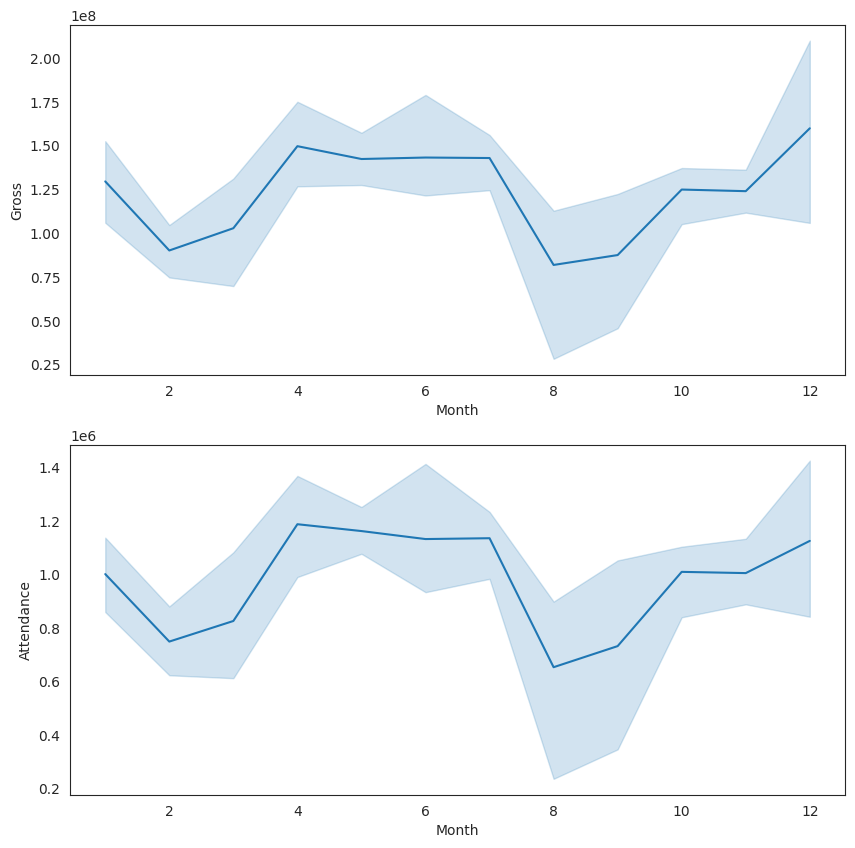

In [3]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize = (10,10))

sns.lineplot(ax= ax[0],data = pd_weekly_grosses_post_covid[['Year','Month','Gross']].groupby(['Year','Month']).sum(), x="Month",y = "Gross")
sns.lineplot(ax = ax[1], data = pd_weekly_grosses_post_covid[['Year','Month','Attendance']].groupby(['Year','Month']).sum(), x="Month", y = "Attendance")



Months of the year with the largest range of values for both revenue and attendance are from August through December. 

From January through July we se that the distribution of the revenue and attendance.

Both attendance and gross revenue show almost the same seasonality from what can be seen in the previous graphs.

The following scatter plot confirms the correlation for attendance and gross revenue. Which could be pretty intuitive. But one can also think of promotions of 2x1 or discounted tickets on those months with lowest capacity pct. However, with the current data set we can see that it is not the case.

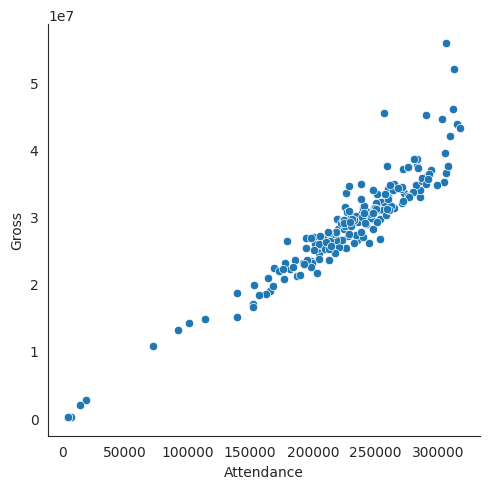

In [4]:
pd_weekly_grosses_post_covid[["Year","Month","Attendance","Gross"]].describe()

sns.relplot(pd_weekly_grosses_post_covid[["Attendance","Gross"]],x='Attendance',y='Gross')

# Shows

In [5]:
df_best_musical = pd.read_csv("/kaggle/input/broadway-datasets/Best_Musical.csv")

# Removing years without an awarded musical
df_best_musical = df_best_musical[df_best_musical["Best Musical"]!='not awarded'].copy().reset_index()

print(df_best_musical.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   index                77 non-null     int64 
 1   ID                   77 non-null     int64 
 2   Year                 77 non-null     int64 
 3   Best Musical         77 non-null     object
 4   Theater              77 non-null     object
 5   Writer/Playwright    77 non-null     object
 6   Writer/Playwright 2  29 non-null     object
 7   Writer/Playwright 3  3 non-null      object
 8   Writer/Playwright 4  2 non-null      object
 9   Composer             77 non-null     object
 10  Lyricist             72 non-null     object
 11  Lyricist 2           20 non-null     object
dtypes: int64(3), object(9)
memory usage: 7.3+ KB
None


In [6]:
df_best_play = pd.read_csv("/kaggle/input/broadway-datasets/Best_Play.csv")

# Removing years without an awarded musical
df_best_play = df_best_play[df_best_play["Best Play"]!='not awarded'].copy().reset_index()

df_best_play.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       78 non-null     int64 
 1   ID          78 non-null     int64 
 2   Year        78 non-null     int64 
 3   Best Play   78 non-null     object
 4   Theater     78 non-null     object
 5   Playwright  78 non-null     object
 6   Translator  4 non-null      object
dtypes: int64(3), object(4)
memory usage: 4.4+ KB


## Top10 Writers/Playwrights With the Most Musical of The Year / Play Of The Year Credits

In [7]:
# Writers/Playwrights for musicals
df_writers_playwrights=pd.melt(df_best_musical[['Year ','Best Musical','Theater','Writer/Playwright','Writer/Playwright 2','Writer/Playwright 3','Writer/Playwright 4']],
    id_vars=['Year ','Best Musical','Theater'],var_name='Ordinal', value_name = 'writer_playwright').copy().dropna()

df_writers_playwrights["writer_playwright"].value_counts().head(10)

writer_playwright
George Abbott           3
Michael Stewart         3
Thomas Meehan           3
Peter Stone             3
Hugh Wheeler            2
Harvey Fierstein        2
Abe Burrows             2
Oscar Hammerstein II    2
Compilation             2
John Logan              2
Name: count, dtype: int64

For musical writer/playright, George Abbot, Michael Stewart, Thomas Meehan and Peter Stone are credited in 3 Best Musical awarder shows.

In [8]:
df_best_play.value_counts('Playwright').head(10)

Playwright
Tom Stoppard        5
Neil Simon          3
Arthur Miller       3
David Edgar         2
August Wilson       2
Harvey Fierstein    2
Terrence McNally    2
Tony Kushner        2
Yasmina Reza        2
Peter Shaffer       2
Name: count, dtype: int64

For Broadway Play authors with most Play Of The Year accolades, Tom Stoppard, Neil Simon and Arthur Miller lead the list.

In [9]:
df_best_play[(df_best_play['Playwright'] == 'Neil Simon') | (df_best_play['Playwright'] == 'Tom Stoppard') | (df_best_play['Playwright'] == 'Arthur Miller')]

,index,ID,Year,Best Play,Theater,Playwright,Translator
0,0,1,1947,All My Sons,Coronet Theatre,Arthur Miller,NaN
2,2,3,1949,Death of a Salesman,Morosco Theatre,Arthur Miller,NaN
6,6,7,1953,The Crucible,Martin Beck Theatre,Arthur Miller,NaN
21,21,22,1968,Rosencrantz and Guildenstern Are Dead,Alvin Theatre,Tom Stoppard,NaN
29,29,30,1976,Travesties,Ethel Barrymore Theatre,Tom Stoppard,NaN
37,37,38,1984,The Real Thing,Plymouth Theatre,Tom Stoppard,NaN
38,38,39,1985,Biloxi Blues,Neil Simon Theatre,Neil Simon,NaN
44,44,45,1991,Lost in Yonkers,Richard Rodgers Theatre,Neil Simon,NaN
60,60,61,2007,The Coast of Utopia,Vivian Beaumont Theater at Lincoln Center,Tom Stoppard,NaN
74,74,75,2021,The Inheritance,Ethel Barrymore Theatre,Tom Stoppard,NaN


## Top10 Theaters with Best Musical Showings

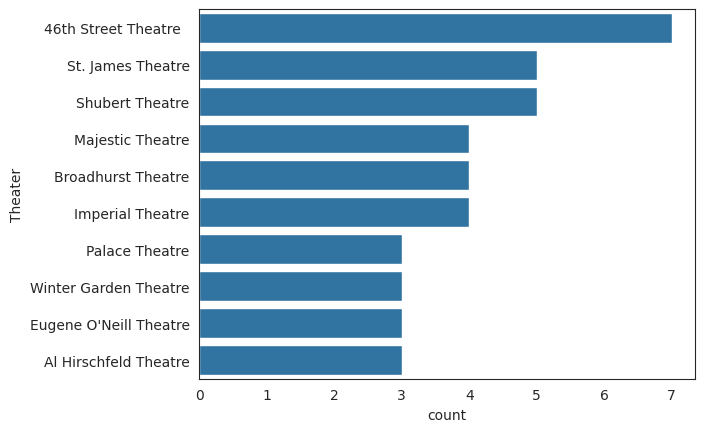

In [10]:
ax = sns.barplot(data=df_best_musical["Theater"].value_counts().head(10), orient='y', width = 0.9, gap = 0.1)

In [11]:
df_best_musical[["Year ","Best Musical"]].groupby('Best Musical').count().reset_index().sort_values('Year ', ascending=False).head(1)

,Best Musical,Year
47,Moulin Rouge! The Musical,2


Moulin Rouge is the only musical that has gotten 'Best Musical' on more than one ocassion.

# Broadway Show Gross Revenue Throughout The Years

To analyze revenue growth we can calculate monthly and yearly amounts and also growth rates for both.

          Gross  Attendance  gross_year_growth  attendance_year_growth
Year                                                                  
1980  107356174     6251615                NaN                     NaN
1981  219354896    10596924           1.043244                0.695070
1982  207061074     8831792          -0.056045               -0.166570
1983  290125845    10790929           0.401161                0.221828
1984  230559040     7962013          -0.205314               -0.262157


<Axes: xlabel='Year', ylabel='gross_year_growth'>

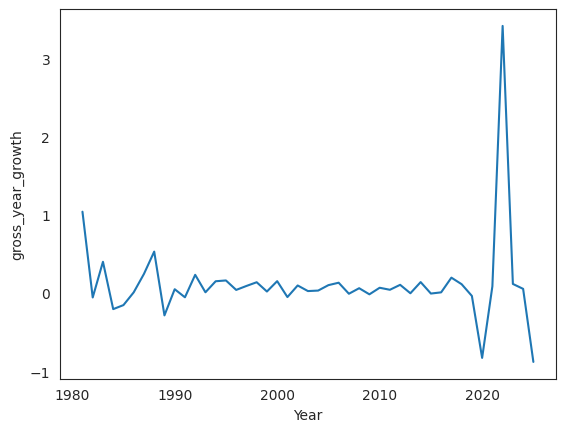

In [12]:
df_yearly_gross = pd_weekly_grosses[['Year','Gross','Attendance']].groupby('Year').sum()

df_yearly_gross['gross_year_growth'] = ((df_yearly_gross['Gross']-df_yearly_gross['Gross'].shift(1)) / df_yearly_gross['Gross'].shift(1))
df_yearly_gross['attendance_year_growth'] = ((df_yearly_gross['Attendance']- df_yearly_gross['Attendance'].shift(1))/ df_yearly_gross['Attendance'].shift(1))

print(df_yearly_gross.head(5))

sns.lineplot(df_yearly_gross,x='Year',y='gross_year_growth')

We se some gross/attendance spikes in the 80s with a corresponding drop in subsequent years. We then see somewhat steady numbers across the 90s all they way down to covid on 2019-2020.